# RGCCA - cas pratique gliome (version corrigee)

Ce notebook reproduit la procedure du papier *Regularized Generalized Canonical
Correlation Analysis* (Tenenhaus et al., JSS 2025), section 4.2 "The glioma
case study", et l'applique aux donnees pre-decoupees fournies dans `data/`.

**Differences cles avec la version precedente du notebook :**

| Point                       | Avant                                       | Maintenant (papier)                              |
|-----------------------------|---------------------------------------------|--------------------------------------------------|
| Nombre de blocs             | 2 (GE, CGH)                                 | **3 (GE, CGH, y)** -- y est le bloc reponse      |
| Methode                     | `rgcca` non supervise, `tau = 1`            | **`sgcca` supervise**, `response = 3`            |
| Selection de variables      | top-variance hors-cible                     | **sparsite L1** tunee par CV                     |
| Classifieur                 | `multinom` (regression logistique)          | **LDA** sur les composantes latentes             |
| Nb de composantes par bloc  | 2                                           | 1 (comme dans le papier)                         |
| Cross-validation            | maison                                      | **`rgcca_cv()`** (kfold = 7, n_run = 3)          |
| Metrique optimisee          | balanced accuracy maison                    | `metric = "Balanced_Accuracy"`                   |

Le papier rapporte une balanced accuracy en validation croisee d'environ
**0.826** et une accuracy en test d'environ **0.92** sur le meme split.

## 1. Setup

In [2]:
set.seed(42)

required_packages <- c("RGCCA", "data.table", "caret", "MASS", "e1071", "kernlab", "randomForest", "gbm", "glmnet", "klaR")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace,
                                              logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(RGCCA)
  library(data.table)
  library(caret)
})

SEED <- 42
LABEL_ORDER <- c("cort", "dipg", "midl")

## 2. Chargement des donnees

On reprend la logique de chargement de la version precedente (CSV pre-splittes).
Les donnees brutes proviennent du jeu `gliomaData::ge_cgh_locIGR` (53 patients,
15702 genes, 1229 segments CGH, 3 localisations).

In [3]:
root <- normalizePath(file.path(getwd()), winslash = "/", mustWork = FALSE)
data_dir <- if (dir.exists(file.path(root, "data"))) file.path(root, "data") else file.path(dirname(root), "data")

to_numeric_frame <- function(df) {
  rn <- rownames(df)
  out <- as.data.frame(
    lapply(df, function(x) as.numeric(gsub(",", ".", as.character(x), fixed = TRUE))),
    check.names = FALSE
  )
  rownames(out) <- rn
  out
}

extract_id_column <- function(df) {
  if ("row_id" %in% names(df)) return("row_id")
  names(df)[1]
}

load_block <- function(block_name, split) {
  path <- file.path(data_dir, sprintf("ge_cgh_locIGR__multiblocks__%s__%s.csv",
                                      block_name, split))
  df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(df)
  rownames(df) <- as.character(df[[id_col]])
  df[[id_col]] <- NULL
  to_numeric_frame(df)
}

load_targets <- function(split) {
  path <- file.path(data_dir, sprintf("ge_cgh_locIGR__multiblocks__y__%s.csv", split))
  y_df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(y_df)
  rownames(y_df) <- as.character(y_df[[id_col]])
  y_df[[id_col]] <- NULL
  targets <- factor(LABEL_ORDER[max.col(as.matrix(y_df[, LABEL_ORDER]),
                                        ties.method = "first")],
                    levels = LABEL_ORDER)
  names(targets) <- rownames(y_df)
  targets
}

fill_missing_from_train <- function(train_df, test_df) {
  medians <- vapply(train_df, median, numeric(1), na.rm = TRUE)
  for (col in names(train_df)) {
    train_df[[col]][is.na(train_df[[col]])] <- medians[[col]]
    test_df[[col]][is.na(test_df[[col]])] <- medians[[col]]
  }
  list(train = train_df, test = test_df)
}

X_ge_train  <- load_block("GE",  "train")
X_ge_test   <- load_block("GE",  "test")
X_cgh_train <- load_block("CGH", "train")
X_cgh_test  <- load_block("CGH", "test")
y_train     <- load_targets("train")
y_test      <- load_targets("test")

# Aligner les blocs sur les memes IDs patients
train_ids <- Reduce(intersect, list(rownames(X_ge_train), rownames(X_cgh_train), names(y_train)))
test_ids  <- Reduce(intersect, list(rownames(X_ge_test),  rownames(X_cgh_test),  names(y_test)))

X_ge_train  <- X_ge_train [train_ids, , drop = FALSE]
X_cgh_train <- X_cgh_train[train_ids, , drop = FALSE]
y_train     <- y_train    [train_ids]

X_ge_test   <- X_ge_test  [test_ids,  , drop = FALSE]
X_cgh_test  <- X_cgh_test [test_ids,  , drop = FALSE]
y_test      <- y_test     [test_ids]

# Imputation des NA par la mediane du train
filled_ge  <- fill_missing_from_train(X_ge_train,  X_ge_test)
X_ge_train <- filled_ge$train ; X_ge_test  <- filled_ge$test
filled_cgh  <- fill_missing_from_train(X_cgh_train, X_cgh_test)
X_cgh_train <- filled_cgh$train ; X_cgh_test <- filled_cgh$test

cat("DATA_DIR :", data_dir, "\n")
cat("Train :", length(y_train), "patients | Test :", length(y_test), "patients\n")
cat("GE :", ncol(X_ge_train), "variables | CGH :", ncol(X_cgh_train), "variables\n")
print(table(train = y_train))
print(table(test  = y_test))

DATA_DIR : /Users/ruben/Documents/Brain-Cancer-Prediction-Model/data 
Train : 39 patients | Test : 14 patients
GE : 15702 variables | CGH : 1229 variables
train
cort dipg midl 
  15   16    8 
test
cort dipg midl 
   5    6    3 


## 3. Construction des blocs multibloc (3 blocs, supervise)

Point cle : la cible `y` devient le **3eme bloc** sous forme de facteur. La
fonction `rgcca()` / `rgcca_cv()` se charge automatiquement du one-hot
encoding et fixe `tau_3 = 0` (ce qui transforme RGCCA en MCOA-style supervise
sur le bloc reponse, voir section 4.2 du papier).

In [4]:
training <- list(
  GE  = as.matrix(X_ge_train),
  CGH = as.matrix(X_cgh_train),
  y   = y_train
)

testing <- list(
  GE  = as.matrix(X_ge_test),
  CGH = as.matrix(X_cgh_test),
  y   = y_test
)

vapply(training, NCOL, FUN.VALUE = 1L)

GE   CGH     y 
15702  1229     1

## 4. Selection des parametres de sparsite par cross-validation

On reproduit l'appel `rgcca_cv()` du papier :

- `par_type = "sparsity"` -> on tune la sparsite L1 de SGCCA
- `par_value = c(0.2, 0.2, 0)` -> bornes superieures pour GE et CGH ;
  la valeur du bloc reponse est ignoree et fixee a 0.
- `par_length = 10` -> 10 sets de sparsite explores (de 1/sqrt(p) a 0.2)
- `prediction_model = "lda"` -> LDA sur les composantes latentes
- `metric = "Balanced_Accuracy"` -> la metrique optimisee
- `validation = "kfold", k = 7, n_run = 3` -> 7-fold repete 3 fois

Cela peut prendre quelques minutes (la dimension dual de RGCCA aide beaucoup,
voir page 32 du papier).

In [5]:
set.seed(SEED)

cv_out <- rgcca_cv(
  blocks            = training,
  response          = 3,
  par_type          = "sparsity",
  par_value         = c(0.2, 0.2, 0),
  par_length        = 10,
  prediction_model  = "lda",
  validation        = "kfold",
  k                 = 7,
  n_run             = 3,
  metric            = "Balanced_Accuracy",
  n_cores           = 1
)

summary(cv_out)

Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0475776846837835. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0475776846837835. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for b

Call: method='sgcca', superblock=FALSE, scale=TRUE, scale_block=TRUE, init='svd',
bias=TRUE, tol=1e-08, NA_method='na.ignore', ncomp=c(1,1,1), response=3,
comp_orth=TRUE 
There are J = 3 blocks.
The design matrix is:
    GE CGH y
GE   0   0 1
CGH  0   0 1
y    1   1 0

The factorial scheme is used.

Tuning parameters (sparsity) used: 
      GE   CGH y
1  0.200 0.200 0
2  0.179 0.181 0
3  0.157 0.162 0
4  0.136 0.143 0
5  0.115 0.124 0
6  0.093 0.105 0
7  0.072 0.086 0
8  0.051 0.067 0
9  0.029 0.048 0
10 0.008 0.029 0

Validation: kfold with 7 folds and 3 run(s)) 
Prediction model: lda 

   Tuning parameters Mean Balanced_Accuracy    Sd
1              Set 1                  0.731 0.161
2              Set 2                  0.726 0.167
3              Set 3                  0.734 0.174
4              Set 4                  0.734 0.169
5              Set 5                  0.764 0.163
6              Set 6                  0.785 0.173
7              Set 7                  0.792 0.150
8    

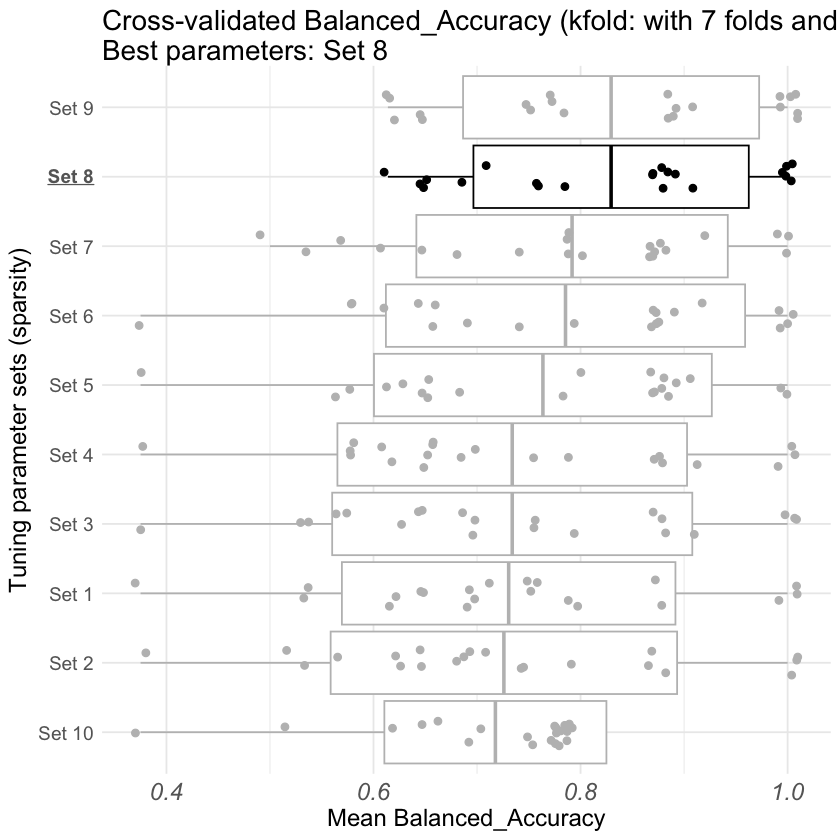

In [6]:
plot(cv_out, cex = 1.2)

## 5. Ajustement du modele optimal

`rgcca(cv_out)` recupere automatiquement les meilleurs parametres trouves par
la CV et ajuste le modele final sur tout le jeu d'entrainement.

In [7]:
fit <- rgcca(cv_out)
summary(fit)

Call: method='sgcca', superblock=FALSE, scale=TRUE, scale_block=TRUE, init='svd',
bias=TRUE, tol=1e-08, NA_method='na.ignore', ncomp=c(1,1,1), response=3,
comp_orth=TRUE 
There are J = 3 blocks.
The design matrix is:
    GE CGH y
GE   0   0 1
CGH  0   0 1
y    1   1 0

The factorial scheme is used.
Sum_{j,k} c_jk g(cov(X_j a_j, X_k a_k) = 0.0042 

The sparsity parameter used for GE is: 0.05065139 (with 68 variables selected)
The sparsity parameter used for CGH is: 0.06663047 (with 11 variables selected)
The regularization parameter used for y is: 0



## 6. Prediction sur le set de test

`rgcca_predict()` projette les blocs de test dans l'espace latent appris,
puis reentraine le classifieur (LDA ici) sur les composantes du train et
predit les etiquettes du test. Sortie : matrice de confusion + metriques
detaillees grace a `caret::confusionMatrix`.

In [8]:
pred <- rgcca_predict(fit, blocks_test = testing, prediction_model = "lda")

cat("=== Matrice de confusion (test) - LDA ===\n")
print(pred$confusion$test)

# Balanced accuracy moyenne (moyenne des balanced accuracy par classe)
bal_acc_per_class <- pred$confusion$test$byClass[, "Balanced Accuracy"]
mean_bal_acc <- mean(bal_acc_per_class)
overall_acc  <- pred$confusion$test$overall[["Accuracy"]]

cat(sprintf("\nAccuracy globale       : %.3f\n", overall_acc))
cat(sprintf("Balanced accuracy moy. : %.3f\n", mean_bal_acc))
cat("\nBalanced accuracy par classe :\n")
print(round(bal_acc_per_class, 3))

=== Matrice de confusion (test) - LDA ===
Confusion Matrix and Statistics

          Reference
Prediction cort dipg midl
      cort    5    0    0
      dipg    0    6    1
      midl    0    0    2

Overall Statistics
                                          
               Accuracy : 0.9286          
                 95% CI : (0.6613, 0.9982)
    No Information Rate : 0.4286          
    P-Value [Acc > NIR] : 0.0001387       
                                          
                  Kappa : 0.8862          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: cort Class: dipg Class: midl
Sensitivity               1.0000      1.0000      0.6667
Specificity               1.0000      0.8750      1.0000
Pos Pred Value            1.0000      0.8571      1.0000
Neg Pred Value            1.0000      1.0000      0.9167
Prevalence                0.3571      0.4286      0.2143
Detection Rate            0.3

## 6b. Comparaison de plusieurs classifieurs en nested CV

On compare plusieurs classifieurs sur les composantes latentes avec une vraie
nested CV : boucle externe sur le train, tuning interne de SGCCA, puis
entraînement du classifieur sur les projections du train externe et évaluation
sur le fold externe. Le test fixe reste reserve a l'evaluation finale du meilleur
classifieur.

In [9]:
classifier_methods <- c(
  lda = "lda",
  svm = "svmLinear",
  rf = "rf",
  gbm = "gbm",
  glmnet = "glmnet",
  nb = "nb"
)

subset_blocks <- function(blocks, idx) {
  lapply(blocks, function(block) {
    if (is.factor(block)) {
      factor(block[idx], levels = levels(block))
    } else {
      block[idx, , drop = FALSE]
    }
  })
}

extract_latent_features <- function(rgcca_fit, blocks) {
  proj <- rgcca_transform(rgcca_fit, blocks_test = blocks)
  data.frame(
    GE = proj$GE[, 1],
    CGH = proj$CGH[, 1],
    row.names = rownames(proj$GE)
  )
}

# Create robust tuneGrids for each classifier (especially for small data with few predictors)
get_tune_grid <- function(method_name) {
  switch(method_name,
    lda = NULL,  # No tuning needed for LDA
    nb = NULL,   # No tuning needed for Naive Bayes
    svmLinear = expand.grid(C = c(0.1, 1)),
    rf = expand.grid(mtry = 1),  # Only 2 predictors (GE, CGH), so mtry=1
    gbm = expand.grid(
      n.trees = c(50, 100),
      interaction.depth = 1,
      shrinkage = 0.1,
      n.minobsinnode = 1
    ),
    glmnet = expand.grid(
      alpha = c(0.5, 1),  # ridge and lasso blend
      lambda = c(0.001, 0.01)
    ),
    NULL  # Default: no specific grid
  )
}

evaluate_nested_classifier <- function(classifier_key, blocks, outer_k = 5, outer_repeats = 3,
                                       inner_k = 5, inner_run = 1, par_length = 5,
                                       seed = SEED) {
  method_name <- classifier_methods[[classifier_key]]
  outer_folds <- caret::createMultiFolds(blocks$y, k = outer_k, times = outer_repeats)
  fold_results <- vector("list", length(outer_folds))

  for (i in seq_along(outer_folds)) {
    idx_train <- outer_folds[[i]]
    idx_valid <- setdiff(seq_along(blocks$y), idx_train)

    train_blocks <- subset_blocks(blocks, idx_train)
    valid_blocks <- subset_blocks(blocks, idx_valid)

    set.seed(seed + i)
    cv_out <- rgcca_cv(
      blocks           = train_blocks,
      response         = 3,
      par_type         = "sparsity",
      par_value        = c(0.2, 0.2, 0),
      par_length       = par_length,
      prediction_model = "lda",
      validation       = "kfold",
      k                = inner_k,
      n_run            = inner_run,
      metric           = "Balanced_Accuracy",
      n_cores          = 1
    )

    fit_outer <- rgcca(cv_out)
    x_train <- extract_latent_features(fit_outer, train_blocks)
    x_valid <- extract_latent_features(fit_outer, valid_blocks)
    y_train_fold <- train_blocks$y
    y_valid_fold <- valid_blocks$y

    # Remove near-zero variance predictors
    nzv <- caret::nearZeroVar(x_train, saveMetrics = FALSE)
    if (length(nzv) > 0) {
      x_train <- x_train[, -nzv, drop = FALSE]
      x_valid <- x_valid[, -nzv, drop = FALSE]
    }

    # Safety checks: need at least one predictor and >=2 classes
    if (ncol(x_train) == 0 || length(unique(y_train_fold)) < 2) {
      fold_results[[i]] <- data.frame(
        Fold = i,
        Classifier = classifier_key,
        Accuracy = NA_real_,
        Balanced_Accuracy = NA_real_
      )
      next
    }

    # Get tuneGrid for this method
    tune_grid <- get_tune_grid(method_name)

    # Train with error capture
    train_args <- list(
      x = x_train,
      y = y_train_fold,
      method = method_name,
      preProcess = c("center", "scale"),
      trControl = caret::trainControl(method = "cv", number = 3)
    )

    if (!is.null(tune_grid)) {
      train_args$tuneGrid <- tune_grid
    }

    train_res <- tryCatch({
      do.call(caret::train, train_args)
    }, error = function(e) {
      message(sprintf("Fold %d - training failed for %s: %s", i, classifier_key, conditionMessage(e)))
      NULL
    })

    if (is.null(train_res)) {
      fold_results[[i]] <- data.frame(
        Fold = i,
        Classifier = classifier_key,
        Accuracy = NA_real_,
        Balanced_Accuracy = NA_real_
      )
      next
    }

    pred_valid <- tryCatch(predict(train_res, newdata = x_valid), error = function(e) NULL)
    if (is.null(pred_valid)) {
      fold_results[[i]] <- data.frame(
        Fold = i,
        Classifier = classifier_key,
        Accuracy = NA_real_,
        Balanced_Accuracy = NA_real_
      )
      next
    }

    cm <- caret::confusionMatrix(
      factor(pred_valid, levels = levels(y_valid_fold)),
      factor(y_valid_fold, levels = levels(y_valid_fold))
    )

    fold_results[[i]] <- data.frame(
      Fold = i,
      Classifier = classifier_key,
      Accuracy = unname(cm$overall[["Accuracy"]]),
      Balanced_Accuracy = mean(cm$byClass[, "Balanced Accuracy"], na.rm = TRUE)
    )
  }

  do.call(rbind, fold_results)
}

In [10]:
set.seed(SEED)

nested_results <- lapply(names(classifier_methods), function(clf) {
  cat(sprintf("\n=== Nested CV pour %s ===\n", clf))
  res <- evaluate_nested_classifier(clf, training)
  cat(sprintf(
    "Mean Accuracy         : %.4f\nMean Balanced Accuracy: %.4f\n",
    mean(res$Accuracy, na.rm = TRUE),
    mean(res$Balanced_Accuracy, na.rm = TRUE)
  ))
  res
})

nested_results_df <- do.call(rbind, nested_results)

nested_summary <- aggregate(
  cbind(Accuracy, Balanced_Accuracy) ~ Classifier,
  data = nested_results_df,
  FUN = function(x) c(mean = mean(x, na.rm = TRUE), sd = sd(x, na.rm = TRUE))
)

nested_summary <- data.frame(
  Classifier = nested_summary$Classifier,
  Accuracy_mean = nested_summary$Accuracy[, "mean"],
  Accuracy_sd = nested_summary$Accuracy[, "sd"],
  Balanced_Accuracy_mean = nested_summary$Balanced_Accuracy[, "mean"],
  Balanced_Accuracy_sd = nested_summary$Balanced_Accuracy[, "sd"],
  row.names = NULL
)

nested_summary <- nested_summary[order(nested_summary$Balanced_Accuracy_mean, decreasing = TRUE), ]

cat("\n\n========== COMPARAISON NESTED CV ==========\n")
print(nested_summary)

best_classifier <- nested_summary$Classifier[1]
cat(sprintf("\n--- Meilleur classifieur selon la nested CV : %s ---\n", best_classifier))


=== Nested CV pour lda ===


Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for b

Mean Accuracy         : 0.6967
Mean Balanced Accuracy: 0.7651

=== Nested CV pour svm ===


Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for b

Mean Accuracy         : 0.7101
Mean Balanced Accuracy: 0.7491

=== Nested CV pour rf ===


...

Iter   TrainDeviance   ValidDeviance   StepSize   Improve
     1        1.0986             nan     0.1000    0.2629
     2        0.9089             nan     0.1000    0.2437
     3        0.7499             nan     0.1000    0.1727
     4        0.6307             nan     0.1000    0.1584
     5        0.5354             nan     0.1000    0.0857
     6        0.4656             nan     0.1000    0.0941
     7        0.3949             nan     0.1000    0.0674
     8        0.3439             nan     0.1000    0.0264
     9        0.3100             nan     0.1000    0.0259
    10        0.2857             nan     0.1000    0.0319
    20        0.1310             nan     0.1000   -0.0014
    40        0.0332             nan     0.1000   -0.0020
    60        0.0158             nan     0.1000   -0.0054
    80        0.0117             nan     0.1000   -0.0006
   100        0.0036             nan     0.1000   -0.0008

Iter   TrainDeviance   ValidDeviance   StepSize   Improve
     1       

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground

Mean Accuracy         : 0.6358
Mean Balanced Accuracy: 0.7299

=== Nested CV pour nb ===


Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0713936714519424. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0713936714519424. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0285248952692565. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for b

Mean Accuracy         : 0.6419
Mean Balanced Accuracy: 0.7408


========== COMPARAISON NESTED CV ==========
  Classifier Accuracy_mean Accuracy_sd Balanced_Accuracy_mean
3        lda     0.6966931   0.1709113              0.7651058
1        gbm     0.6789683   0.1640413              0.7604233
5         rf     0.6837302   0.1475777              0.7563228
6        svm     0.7100529   0.1751031              0.7491005
4         nb     0.6419312   0.1939896              0.7408466
2     glmnet     0.6358466   0.1991114              0.7298942
  Balanced_Accuracy_sd
3            0.1363831
1            0.1354748
5            0.1197094
6            0.1363065
4            0.1434828
2            0.1579818

--- Meilleur classifieur selon la nested CV : lda ---


In [11]:
final_train_features <- extract_latent_features(fit, training)
final_test_features  <- extract_latent_features(fit, testing)

final_results <- lapply(names(classifier_methods), function(clf) {
  method_name <- classifier_methods[[clf]]
  
  # Get tuneGrid for this method
  tune_grid <- get_tune_grid(method_name)
  
  train_args <- list(
    x = final_train_features,
    y = y_train,
    method = method_name,
    preProcess = c("center", "scale"),
    trControl = caret::trainControl(method = "cv", number = 5)
  )
  
  if (!is.null(tune_grid)) {
    train_args$tuneGrid <- tune_grid
  }
  
  clf_fit <- tryCatch({
    do.call(caret::train, train_args)
  }, error = function(e) {
    message(sprintf("Final training failed for %s: %s", clf, conditionMessage(e)))
    NULL
  })
  
  if (is.null(clf_fit)) {
    return(data.frame(
      Classifier = clf,
      Test_Accuracy = NA_real_,
      Test_Balanced_Accuracy = NA_real_,
      row.names = NULL
    ))
  }

  pred_test <- tryCatch(predict(clf_fit, newdata = final_test_features), 
                        error = function(e) NULL)
  
  if (is.null(pred_test)) {
    return(data.frame(
      Classifier = clf,
      Test_Accuracy = NA_real_,
      Test_Balanced_Accuracy = NA_real_,
      row.names = NULL
    ))
  }
  
  cm <- caret::confusionMatrix(
    factor(pred_test, levels = levels(y_test)),
    factor(y_test, levels = levels(y_test))
  )

  data.frame(
    Classifier = clf,
    Test_Accuracy = unname(cm$overall[["Accuracy"]]),
    Test_Balanced_Accuracy = mean(cm$byClass[, "Balanced Accuracy"], na.rm = TRUE),
    row.names = NULL
  )
})

final_results_df <- do.call(rbind, final_results)
final_results_df <- final_results_df[order(final_results_df$Test_Balanced_Accuracy, decreasing = TRUE), ]

cat("\n========== EVALUATION FINALE SUR LE TEST ==========\n")
print(final_results_df)

cat(sprintf(
  "\nMeilleur classifieur final : %s (BA test = %.4f)\n",
  final_results_df$Classifier[1],
  final_results_df$Test_Balanced_Accuracy[1]
))

Iter   TrainDeviance   ValidDeviance   StepSize   Improve
     1        1.0986             nan     0.1000    0.3456
     2        0.8920             nan     0.1000    0.2322
     3        0.7416             nan     0.1000    0.1717
     4        0.6288             nan     0.1000    0.1325
     5        0.5401             nan     0.1000    0.1360
     6        0.4559             nan     0.1000    0.0616
     7        0.4079             nan     0.1000    0.0774
     8        0.3576             nan     0.1000    0.0657
     9        0.3114             nan     0.1000    0.0550
    10        0.2766             nan     0.1000    0.0378
    20        0.0928             nan     0.1000   -0.0027
    40        0.0210             nan     0.1000   -0.0024
    60        0.0083             nan     0.1000    0.0002
    80        0.0030             nan     0.1000   -0.0003
   100        0.0013             nan     0.1000   -0.0004

Iter   TrainDeviance   ValidDeviance   StepSize   Improve
     1       

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground


========== EVALUATION FINALE SUR LE TEST ==========
  Classifier Test_Accuracy Test_Balanced_Accuracy
1        lda     0.9285714              0.9236111
2        svm     0.9285714              0.9236111
3         rf     0.7857143              0.8321970
4        gbm     0.7857143              0.8321970
5     glmnet     0.7857143              0.8321970
6         nb     0.7857143              0.8321970

Meilleur classifieur final : lda (BA test = 0.9236)


## 7. Visualisation des composantes latentes

Avec `ncomp = 1` par bloc, on a une composante GE et une composante CGH par
patient : on les croise pour voir la separation des 3 localisations.

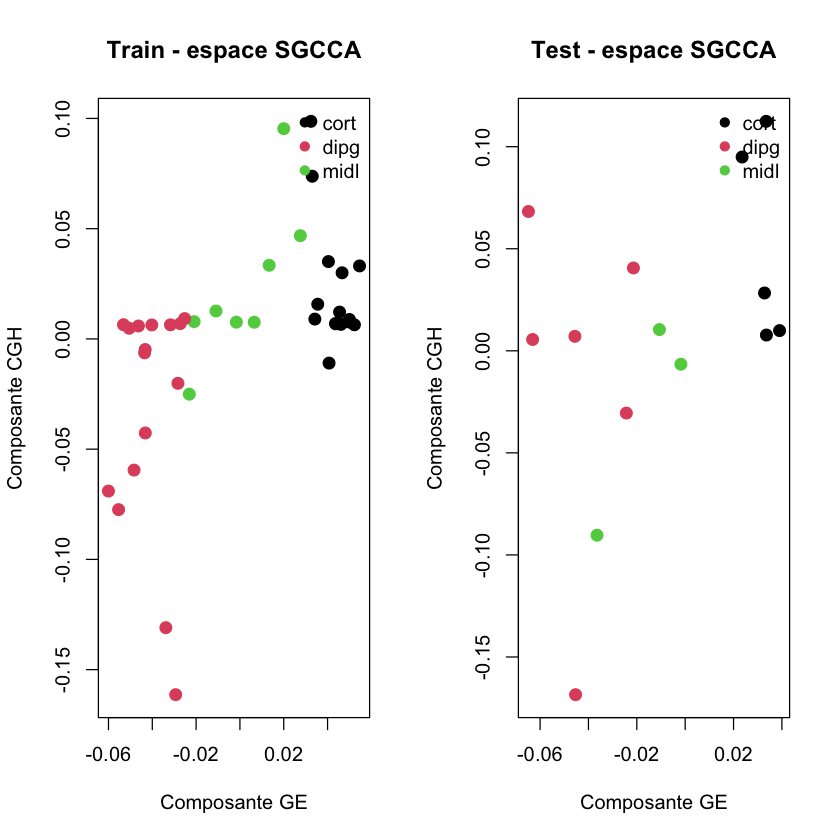

In [12]:
proj_train <- rgcca_transform(fit, blocks_test = training)
proj_test  <- rgcca_transform(fit, blocks_test = testing)

par(mfrow = c(1, 2))
plot(proj_train$GE[, 1], proj_train$CGH[, 1],
     col = as.integer(y_train), pch = 19, cex = 1.3,
     xlab = "Composante GE",  ylab = "Composante CGH",
     main = "Train - espace SGCCA")
legend("topright", legend = levels(y_train),
       col = seq_along(levels(y_train)), pch = 19, bty = "n")

plot(proj_test$GE[, 1], proj_test$CGH[, 1],
     col = as.integer(y_test), pch = 19, cex = 1.3,
     xlab = "Composante GE", ylab = "Composante CGH",
     main = "Test - espace SGCCA")
legend("topright", legend = levels(y_test),
       col = seq_along(levels(y_test)), pch = 19, bty = "n")
par(mfrow = c(1, 1))

## 8. (Optionnel) Stabilite des variables selectionnees

`rgcca_stability()` re-ajuste SGCCA sur des bootstraps du train et garde les
variables qui ont les plus hauts scores VIP moyens. Le modele stabilise est
ensuite passe a `rgcca_bootstrap()` pour obtenir des intervalles de confiance
sur les poids -- exactement la procedure de la fin de la section 4.2.

Cellule un peu longue (100 + 500 bootstraps) ; on peut reduire `n_boot` pour
un essai rapide.

Bootstrap samples sanity check...
OK

Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0666304740983106. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0666304740983106. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“The l2 constraint is not saturated for block #2. The intersection of the l1 and l2 spheres is empty for a sparsity parameter equal to 0.0666304740983106. Try to increase the value of the sparsity parameter.”
Warning message in sgcca_postprocess(A, a, Y, g, na.rm, sparsity, tol, response, :
“Th

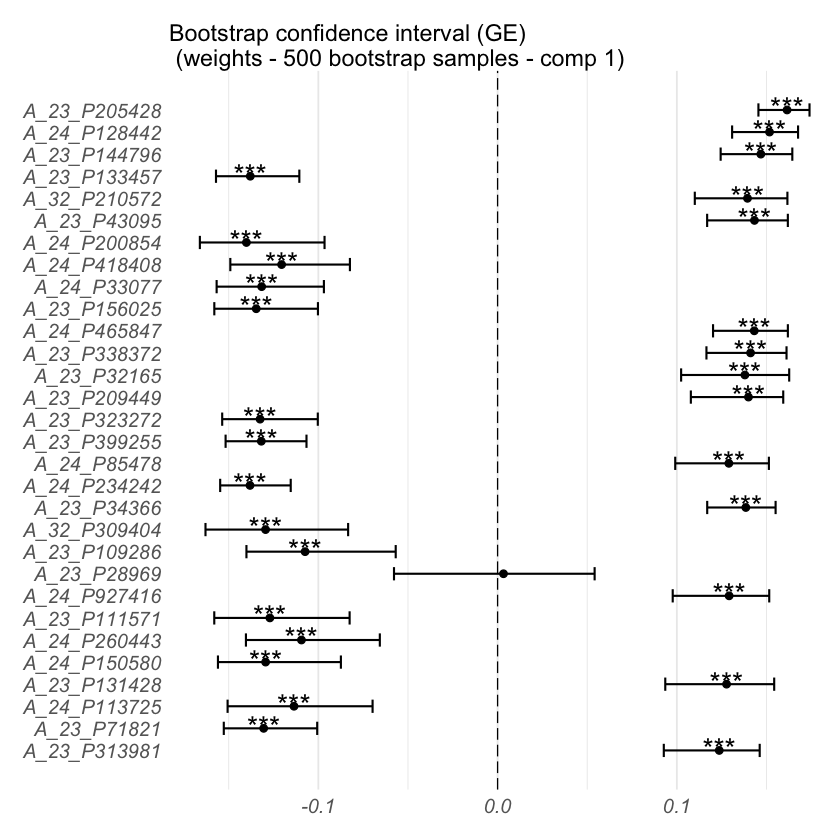

In [13]:
set.seed(SEED)
fit_stab <- rgcca_stability(
  fit,
  keep   = vapply(fit$a, function(x) mean(x != 0), FUN.VALUE = 1.0),
  n_boot = 100
)

set.seed(SEED)
boot_out <- rgcca_bootstrap(fit_stab, n_boot = 500)

# Top variables GE
plot(boot_out, block = 1, display_order = FALSE,
     n_mark = 30, cex = 1.0, show_star = TRUE)

## 9. Notes sur le score attendu

Sur le split du papier (`set.seed(0)` + `caret::createDataPartition(blocks[[3]], p = 0.75)`)
les chiffres rapportes sont :

- **CV (train, 7-fold x 3 runs)** : balanced accuracy ~ 0.826
- **Test (12 patients)** : accuracy ~ 0.917, balanced accuracy ~ 0.893

Si vos CSV pre-splittes ont ete generes avec **un autre seed**, les chiffres
seront un peu differents (le test set ne fait que 12-13 patients, donc 1
patient mal classe deplace l'accuracy de ~8%). Pour reproduire exactement les
chiffres du papier, le plus sur est de partir de `gliomaData::ge_cgh_locIGR`
et de faire le split avec `set.seed(0)`.

GE  : 68 / 15702 variables retenues
CGH : 11 / 1229 variables retenues
                 variable  weight
A_23_P205428 A_23_P205428 -0.4169
A_24_P128442 A_24_P128442 -0.3062
A_23_P144796 A_23_P144796 -0.2489
A_24_P465847 A_24_P465847 -0.2177
A_23_P43095   A_23_P43095 -0.2080
A_32_P210572 A_32_P210572 -0.2050
A_23_P338372 A_23_P338372 -0.1941
A_23_P209449 A_23_P209449 -0.1940
A_23_P133457 A_23_P133457  0.1940
A_24_P200854 A_24_P200854  0.1853
A_24_P234242 A_24_P234242  0.1723
A_23_P32165   A_23_P32165 -0.1634
A_23_P34366   A_23_P34366 -0.1616
A_23_P156025 A_23_P156025  0.1540
A_23_P5968     A_23_P5968 -0.1422
A_23_P399255 A_23_P399255  0.1369
A_23_P254768 A_23_P254768  0.1352
A_24_P33077   A_24_P33077  0.1298
A_24_P17031   A_24_P17031 -0.1191
A_32_P111678 A_32_P111678 -0.1180
     variable  weight
V128     V128  0.6853
V123     V123  0.3973
V124     V124  0.3973
V121     V121  0.3084
V122     V122  0.3084
V763     V763  0.1518
V940     V940 -0.0188
V941     V941 -0.0188
V942     V942 -0.

ERROR: Error in abs(ge_stable$bootstrap_ratio): non-numeric argument to mathematical function


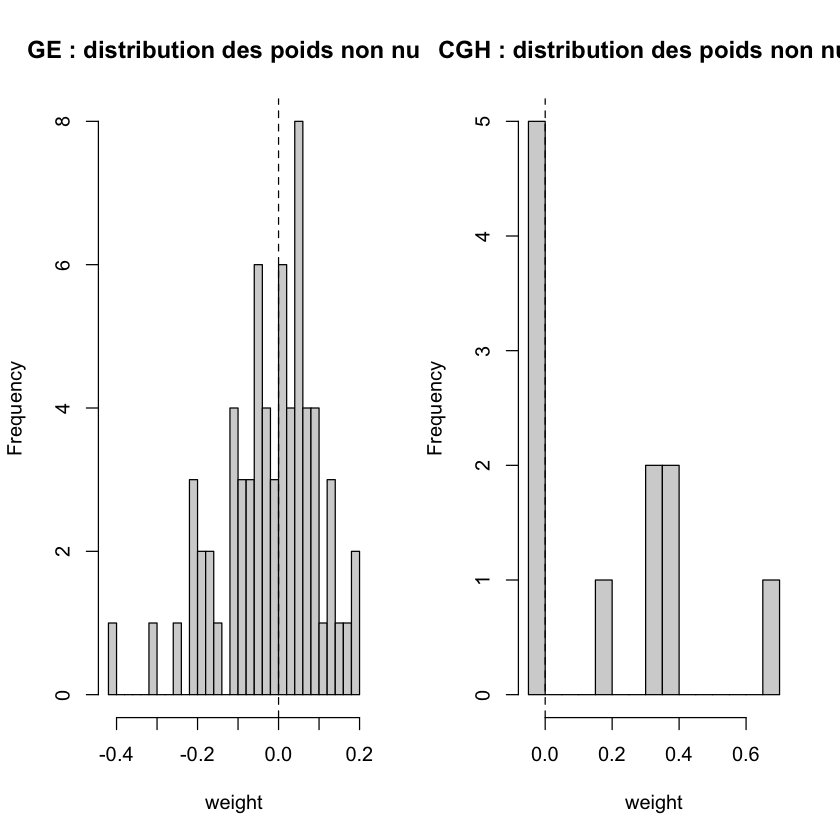

In [14]:
# 1. Quelles variables ont été sélectionnées par bloc ?
selected_ge  <- rownames(fit$a$GE)[abs(fit$a$GE[, 1])  > 1e-8]
selected_cgh <- rownames(fit$a$CGH)[abs(fit$a$CGH[, 1]) > 1e-8]
cat(sprintf("GE  : %d / %d variables retenues\n", length(selected_ge), nrow(fit$a$GE)))
cat(sprintf("CGH : %d / %d variables retenues\n", length(selected_cgh), nrow(fit$a$CGH)))

# 2. Top 20 GE par valeur absolue du poids
ge_weights <- fit$a$GE[, 1]
top20_ge <- sort(abs(ge_weights), decreasing = TRUE)[1:20]
print(data.frame(
  variable = names(top20_ge),
  weight   = round(ge_weights[names(top20_ge)], 4)
))

# 3. Top 11 CGH (tous, puisque seulement 11 sélectionnés)
cgh_weights <- fit$a$CGH[, 1]
nz_cgh <- cgh_weights[abs(cgh_weights) > 1e-8]
print(data.frame(
  variable = names(nz_cgh),
  weight   = round(nz_cgh, 4)
)[order(-abs(nz_cgh)), ])

# 4. Distribution des poids
par(mfrow = c(1, 2))
hist(ge_weights[abs(ge_weights) > 1e-8], breaks = 30,
     main = "GE : distribution des poids non nuls", xlab = "weight")
abline(v = 0, lty = 2)
hist(cgh_weights[abs(cgh_weights) > 1e-8], breaks = 15,
     main = "CGH : distribution des poids non nuls", xlab = "weight")
abline(v = 0, lty = 2)

# 5. Stabilité (si rgcca_bootstrap dispo)
boot_summary <- summary(boot_out)
ge_stable <- boot_summary[boot_summary$block == "GE" & boot_summary$adjust.pval < 0.05, ]
cat(sprintf("\nVariables GE stables (p_adj < 0.05) : %d\n", nrow(ge_stable)))
print(head(ge_stable[order(-abs(ge_stable$bootstrap_ratio)), 
                     c("var", "estimate", "lower_bound", "upper_bound", 
                       "bootstrap_ratio", "adjust.pval")], 20))